# Iris Flower Classification

## OIBSIP Data Science Internship - Task 1

### Objective
The objective of this project is to build machine learning classification
models that can identify the species of an iris flower based on its
physical measurements.

### Dataset
The Iris dataset is a built-in dataset available through scikit-learn.

### Target Classes
- Setosa
- Versicolor
- Virginica

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

## Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plts
import seaborn as sns

from sklearn.datasets import load_iris

## Load the dataset

In [2]:
iris = load_iris()
print("Dataset loaded successfully!")

Dataset loaded successfully!


## Create the DataFrame

In [3]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## EDA

In [4]:
##CHECKING SHAPES
df.shape

(150, 5)

In [5]:
## CHECKING DATA TYPES
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
dtype: object

In [6]:
## CHECK MISSING VALUES
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [7]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [8]:
## Convert species numbers to names
df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [9]:
## Check the species counts
df["species"].value_counts()

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

### EDA Observations

- The dataset contains 150 iris flower samples.
- There are four numerical features: sepal length, sepal width, petal length, and petal width.
- The dataset contains three species: Setosa, Versicolor, and Virginica.
- Each species contains 50 observations, so the classes are balanced.
- The dataset does not contain missing values.
- The four measurement features are numerical and can be used for machine learning classification.

In [ ]:
## Pairplot

## Exploratory Data Visualization

A pairplot is used to visualize the relationships between the numerical features and observe how well the three iris species are separated.

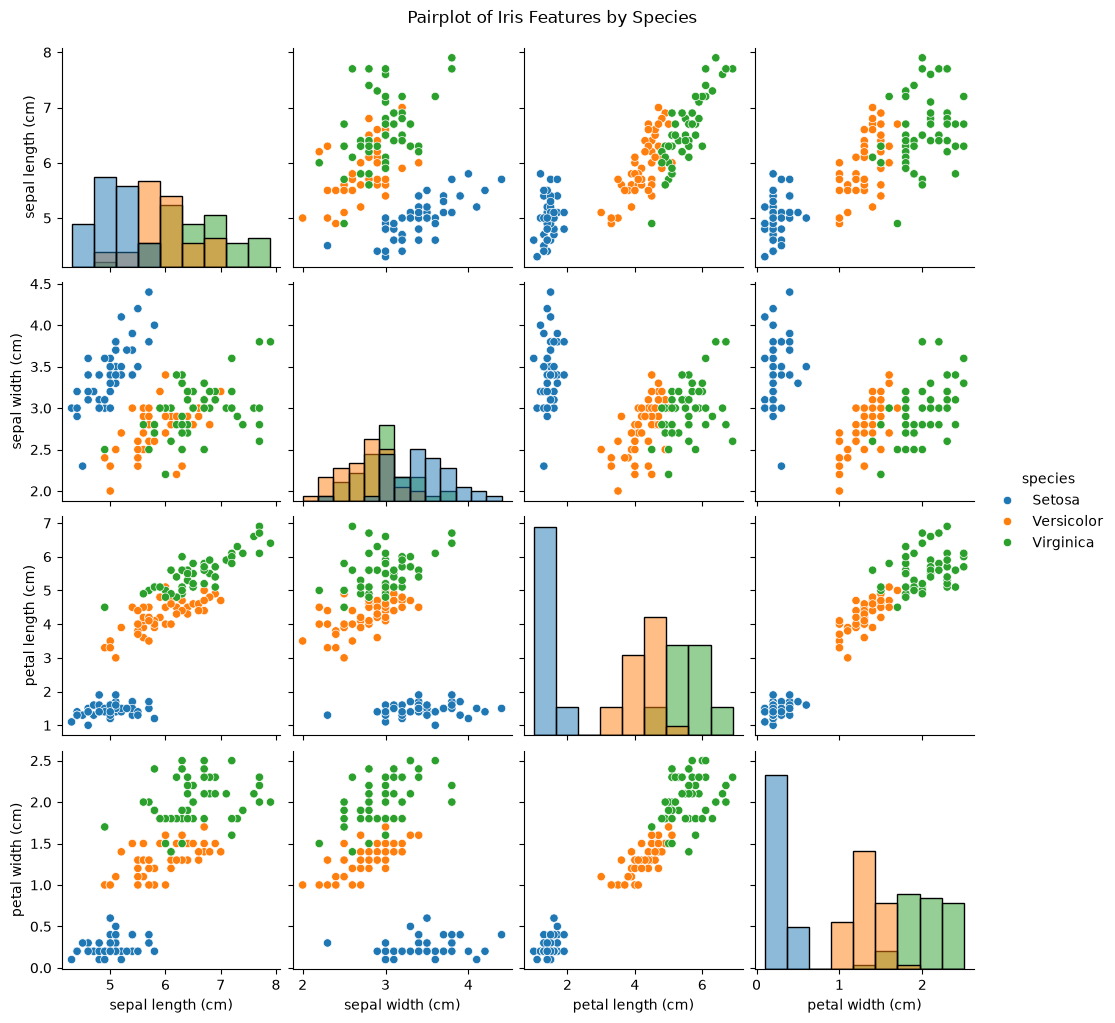

In [10]:
sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

## BOX PLOT

## Box Plot Analysis

Box plots are used to compare the distribution of each numerical feature across the three iris species. They help identify differences in the median, spread, and possible outliers.

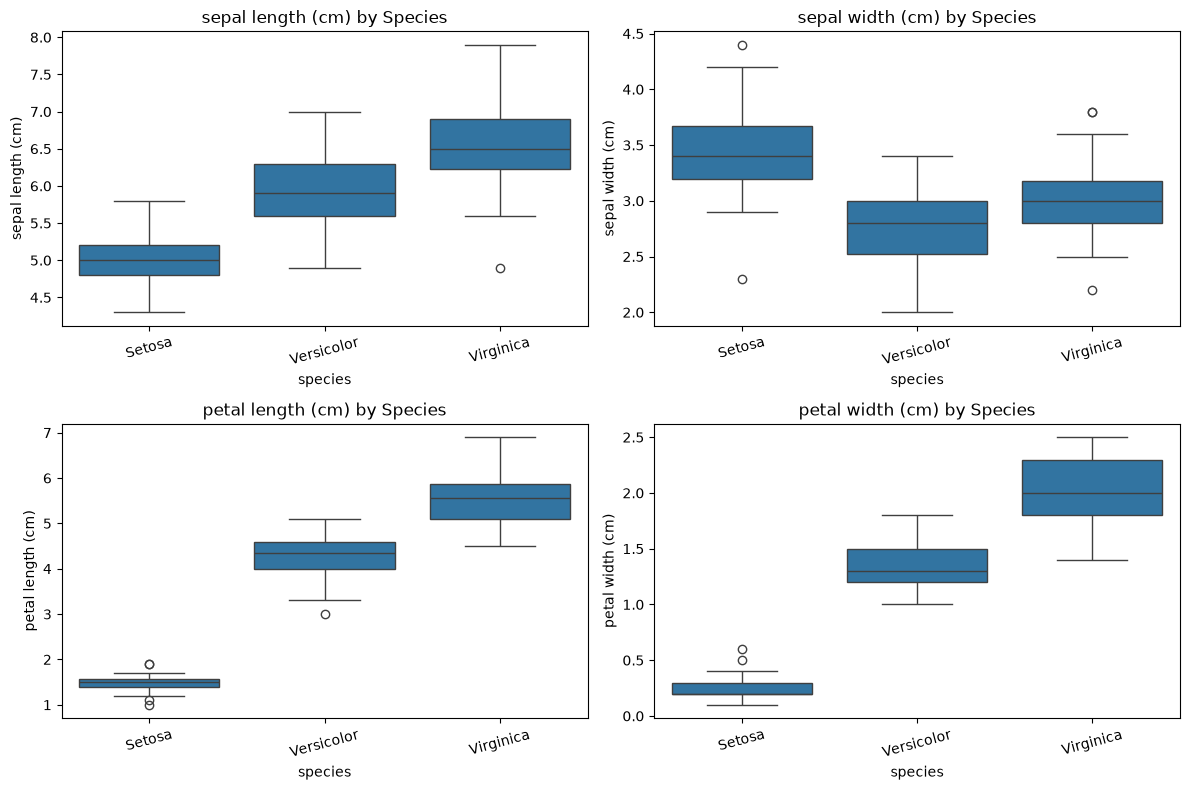

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

features = iris.feature_names

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(
        data=df,
        x="species",
        y=feature,
        ax=ax
    )
    ax.set_title(f"{feature} by Species")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## Feature Selection Discussion

## Feature Selection Discussion

Based on the pairplot and box plots, petal length and petal width appear to be the most discriminative features.

The Setosa species is clearly separated from Versicolor and Virginica using the petal measurements. Versicolor and Virginica also show some separation based on petal length and petal width.

The sepal features show more overlap between the species.

Therefore, petal length and petal width appear to provide stronger discriminatory information for classifying iris species. However, all four features will initially be retained for model training so that the models can use the complete available information.